# Tech Challenge - Fase 2: Otimização dos modelos com Algoritmo Genético + LLM

**Autor:** Gustavo Diniz - Pós-Tech FIAP, Tech Challenge.

**Projeto escolhido:** Projeto 1 - otimização de modelos de diagnóstico.

Na Fase 1 treinei três modelos para triagem de risco de AVC (Regressão Logística,
Árvore de Decisão e Random Forest) com hiperparâmetros escolhidos "no olho".
Nesta fase uso um **algoritmo genético** (implementado do zero em `genetico.py`)
para procurar hiperparâmetros melhores, e depois integro uma **LLM (Google Gemini)**
para explicar as predições em linguagem natural para a equipe médica.

## 1. Setup e carga do dataset

Mesmo dataset e mesma preparação da Fase 1 (mesma seed, mesmo split), para a
comparação entre modelo original e otimizado ser justa.

In [ ]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..') 
from genetico import algoritmo_genetico

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')
df = df[df['gender'] != 'Other'].drop(columns=['id']).reset_index(drop=True)
print(df.shape)

(5109, 11)


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['stroke'])
y = df['stroke']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, stratify=y_trainval, random_state=RANDOM_STATE
)
print(f'Treino: {X_train.shape} | Validação: {X_val.shape} | Teste: {X_test.shape}')

Treino: (3269, 10) | Validação: (818, 10) | Teste: (1022, 10)


In [3]:
# Pré-processamento igual ao da Fase 1
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
binary_features = ['hypertension', 'heart_disease']

def novo_preprocessador():
    return ColumnTransformer(transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('bin', 'passthrough', binary_features),
    ])

## 2. Modelos da Fase 1 (baseline)

Primeiro reavalio os três modelos com os hiperparâmetros originais da Fase 1,
na validação. É contra esses números que o algoritmo genético vai competir.

Além das métricas da Fase 1, incluo o **F2-score**, que dá peso dobrado ao recall.
Como discuti na Fase 1, o erro mais grave aqui é o falso negativo (liberar um
paciente que teve AVC), então recall importa mais que precision - e o F2 resume
isso num número só. Ele vai ser a função fitness do algoritmo genético.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, fbeta_score, roc_auc_score)

def criar_modelo(nome, params):
    if nome == 'Regressão Logística':
        return LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **params)
    if nome == 'Árvore de Decisão':
        return DecisionTreeClassifier(random_state=RANDOM_STATE, **params)
    return RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params)

# hiperparâmetros que usei na Fase 1
params_fase1 = {
    'Regressão Logística': {'class_weight': 'balanced'},
    'Árvore de Decisão': {'max_depth': 6, 'class_weight': 'balanced'},
    'Random Forest': {'n_estimators': 300, 'max_depth': 10, 'class_weight': 'balanced'},
}

def treinar_e_avaliar(nome, params, X_avali, y_avali):
    pipe = Pipeline([('prep', novo_preprocessador()), ('modelo', criar_modelo(nome, params))])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_avali)
    y_proba = pipe.predict_proba(X_avali)[:, 1]
    return pipe, {
        'accuracy': accuracy_score(y_avali, y_pred),
        'precision': precision_score(y_avali, y_pred, zero_division=0),
        'recall': recall_score(y_avali, y_pred),
        'f1': f1_score(y_avali, y_pred),
        'f2': fbeta_score(y_avali, y_pred, beta=2, zero_division=0),
        'roc_auc': roc_auc_score(y_avali, y_proba),
    }

metricas_fase1 = {}
for nome, params in params_fase1.items():
    _, metricas_fase1[nome] = treinar_e_avaliar(nome, params, X_val, y_val)

pd.DataFrame(metricas_fase1).T.round(4)

,accuracy,precision,recall,f1,f2,roc_auc
Regressão Logística,0.7323,0.1434,0.900,0.2474,0.4380,0.8683
Árvore de Decisão,0.7555,0.1330,0.725,0.2248,0.3836,0.7539
Random Forest,0.8741,0.1461,0.325,0.2016,0.2610,0.8284


O Random Forest chama atenção: o ROC-AUC dele é bom (essa métrica mede se o
modelo ordena bem os pacientes por risco, onde 0.5 é chute e 1 é perfeito),
mas o recall é baixo -
ele deixa passar a maioria dos pacientes que tiveram AVC. É o principal
candidato a melhorar com a otimização.

## 3. O algoritmo genético

A implementação está em [`genetico.py`](../genetico.py), na raiz do projeto. A ideia:

- **Indivíduo (cromossomo):** um dicionário `{hiperparâmetro: valor}`. Cada
  hiperparâmetro é um gene, e os valores possíveis de cada gene ficam no
  *espaço de busca* abaixo;
- **Fitness:** F2-score médio em validação cruzada (3 folds) **dentro do treino**.
  Validação e teste ficam de fora, para não vazar informação;
- **Seleção por torneio:** sorteia 3 indivíduos, o de maior fitness vira pai;
- **Cruzamento uniforme:** cada gene do filho vem de um dos pais (50/50);
- **Mutação:** cada gene tem uma chance de ser sorteado de novo;
- **Elitismo:** o melhor indivíduo de cada geração passa direto para a próxima,
  então o melhor resultado nunca piora.

In [5]:
# Espaço de busca de cada modelo (os genes e seus valores possíveis)
espacos = {
    'Regressão Logística': {
        'C': [0.01, 0.1, 0.3, 1, 3, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'class_weight': ['balanced', None],
    },
    'Árvore de Decisão': {
        'max_depth': [3, 4, 6, 8, 10, 15, None],
        'min_samples_split': [2, 5, 10, 20, 30],
        'min_samples_leaf': [1, 2, 5, 10, 20],
        'criterion': ['gini', 'entropy'],
        'class_weight': ['balanced', None],
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 7, 10, 15, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10, 20],
        'max_features': ['sqrt', 'log2', None],
        'class_weight': ['balanced', 'balanced_subsample', None],
    },
}

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

def criar_funcao_fitness(nome_modelo):
    cache = {}  # o GA repete indivíduos; o cache evita reavaliar o mesmo

    def fitness(params):
        chave = str(sorted(params.items()))
        if chave not in cache:
            pipe = Pipeline([('prep', novo_preprocessador()),
                             ('modelo', criar_modelo(nome_modelo, params))])
            notas = cross_val_score(pipe, X_train, y_train, cv=3, scoring=f2_scorer)
            cache[chave] = notas.mean()
        return cache[chave]

    return fitness

## 4. Experimentos

O enunciado pede **pelo menos 3 experimentos com configurações diferentes** do
algoritmo genético. Vario o tamanho da população e a taxa de mutação:

| Experimento | População | Gerações | Mutação |
|---|---|---|---|
| exp1 - base | 12 | 8 | 0.20 |
| exp2 - população maior | 20 | 5 | 0.10 |
| exp3 - mutação alta | 12 | 8 | 0.40 |

Cada experimento roda para os três modelos. O log de cada geração aparece
abaixo e também vai para `results/experimentos.log`, e o histórico de cada
execução é salvo em CSV (monitoramento pedido no enunciado).

In [7]:
import logging

os.makedirs('../results', exist_ok=True)
logging.basicConfig(filename='../results/experimentos.log', level=logging.INFO,
                    format='%(asctime)s %(message)s', force=True)

experimentos = [
    {'nome': 'exp1 - base',            'tam_pop': 12, 'geracoes': 8, 'taxa_mutacao': 0.2},
    {'nome': 'exp2 - população maior', 'tam_pop': 20, 'geracoes': 5, 'taxa_mutacao': 0.1},
    {'nome': 'exp3 - mutação alta',    'tam_pop': 12, 'geracoes': 8, 'taxa_mutacao': 0.4},
]

resultados = []   # métricas de cada modelo otimizado na validação
historicos = {}   # curvas de convergência para os gráficos

for nome_modelo in espacos:
    fitness = criar_funcao_fitness(nome_modelo)
    for exp in experimentos:
        print(f'=== {nome_modelo} | {exp["nome"]} ===')
        logging.info(f'Iniciando {nome_modelo} | {exp["nome"]}')

        melhor, fit, historico = algoritmo_genetico(
            espacos[nome_modelo], fitness,
            tam_pop=exp['tam_pop'], geracoes=exp['geracoes'],
            taxa_mutacao=exp['taxa_mutacao'], seed=RANDOM_STATE)

        historicos[(nome_modelo, exp['nome'])] = historico
        pd.DataFrame(historico).to_csv(
            f"../results/historico_{nome_modelo}_{exp['nome']}.csv", index=False)

        _, metricas = treinar_e_avaliar(nome_modelo, melhor, X_val, y_val)
        resultados.append({'modelo': nome_modelo, 'experimento': exp['nome'],
                           'params': melhor, **metricas})
        logging.info(f'Melhor: {melhor} | F2(cv)={fit:.4f} | validação={metricas}')
        print(f'-> melhor F2 na validação: {metricas["f2"]:.4f} | {melhor}\n')

=== Regressão Logística | exp1 - base ===


geracao 01 | melhor fitness = 0.3805 | media = 0.3166
geracao 02 | melhor fitness = 0.3805 | media = 0.2852


geracao 03 | melhor fitness = 0.3805 | media = 0.3168
geracao 04 | melhor fitness = 0.3805 | media = 0.3804
geracao 05 | melhor fitness = 0.3812 | media = 0.3805
geracao 06 | melhor fitness = 0.3812 | media = 0.3805
geracao 07 | melhor fitness = 0.3812 | media = 0.3173
geracao 08 | melhor fitness = 0.3812 | media = 0.3481


-> melhor F2 na validação: 0.4369 | {'C': 0.1, 'solver': 'liblinear', 'class_weight': 'balanced'}

=== Regressão Logística | exp2 - população maior ===


geracao 01 | melhor fitness = 0.3805 | media = 0.3036
geracao 02 | melhor fitness = 0.3805 | media = 0.3232
geracao 03 | melhor fitness = 0.3805 | media = 0.3613
geracao 04 | melhor fitness = 0.3805 | media = 0.3804
geracao 05 | melhor fitness = 0.3805 | media = 0.3614
-> melhor F2 na validação: 0.4289 | {'C': 3, 'solver': 'lbfgs', 'class_weight': 'balanced'}

=== Regressão Logística | exp3 - mutação alta ===
geracao 01 | melhor fitness = 0.3812 | media = 0.3167
geracao 02 | melhor fitness = 0.3812 | media = 0.2850
geracao 03 | melhor fitness = 0.3812 | media = 0.3478
geracao 04 | melhor fitness = 0.3812 | media = 0.3487
geracao 05 | melhor fitness = 0.3812 | media = 0.3480
geracao 06 | melhor fitness = 0.3812 | media = 0.3486
geracao 07 | melhor fitness = 0.3812 | media = 0.3482
geracao 08 | melhor fitness = 0.3812 | media = 0.2855


...

geracao 05 | melhor fitness = 0.4191 | media = 0.2900


geracao 06 | melhor fitness = 0.4191 | media = 0.2995


geracao 07 | melhor fitness = 0.4191 | media = 0.3388


geracao 08 | melhor fitness = 0.4191 | media = 0.3900


-> melhor F2 na validação: 0.4533 | {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}



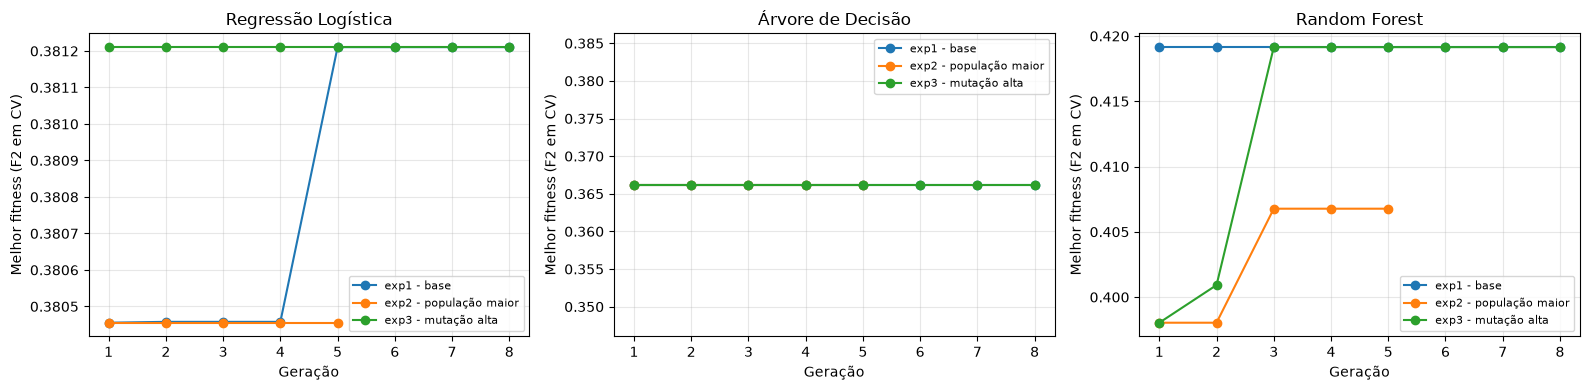

In [8]:
# Curvas de convergência: melhor fitness por geração, em cada experimento
fig, eixos = plt.subplots(1, 3, figsize=(16, 4))
for eixo, nome_modelo in zip(eixos, espacos):
    for exp in experimentos:
        h = pd.DataFrame(historicos[(nome_modelo, exp['nome'])])
        eixo.plot(h['geracao'], h['melhor'], marker='o', label=exp['nome'])
    eixo.set_title(nome_modelo)
    eixo.set_xlabel('Geração')
    eixo.set_ylabel('Melhor fitness (F2 em CV)')
    eixo.grid(alpha=0.3)
    eixo.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Comparação: original vs otimizado

In [9]:
df_resultados = pd.DataFrame(resultados)

comparacao = []
for nome_modelo in espacos:
    comparacao.append({'modelo': nome_modelo, 'versão': 'Fase 1 (original)',
                       **metricas_fase1[nome_modelo]})
    linhas = df_resultados[df_resultados['modelo'] == nome_modelo]
    melhor_linha = linhas.loc[linhas['f2'].idxmax()]
    comparacao.append({'modelo': nome_modelo,
                       'versão': f"otimizado ({melhor_linha['experimento']})",
                       **melhor_linha[['accuracy', 'precision', 'recall', 'f1', 'f2', 'roc_auc']]})

pd.DataFrame(comparacao).round(4)

,modelo,versão,accuracy,precision,recall,f1,f2,roc_auc
0,Regressão Logística,Fase 1 (original),0.7323,0.1434,0.900,0.2474,0.4380,0.8683
1,Regressão Logística,otimizado (exp1 - base),0.7311,0.1429,0.900,0.2466,0.4369,0.8695
2,Árvore de Decisão,Fase 1 (original),0.7555,0.1330,0.725,0.2248,0.3836,0.7539
3,Árvore de Decisão,otimizado (exp1 - base),0.6614,0.1140,0.875,0.2017,0.3747,0.8280
4,Random Forest,Fase 1 (original),0.8741,0.1461,0.325,0.2016,0.2610,0.8284
5,Random Forest,otimizado (exp1 - base),0.7714,0.1581,0.850,0.2667,0.4533,0.8659


In [10]:
# Campeão geral (maior F2 na validação), avaliado UMA vez no teste,
# que ficou intocado durante toda a otimização
campeao = df_resultados.loc[df_resultados['f2'].idxmax()]
print(f"Campeão: {campeao['modelo']} ({campeao['experimento']})")
print(f"Hiperparâmetros: {campeao['params']}")

pipe_campeao, metricas_teste = treinar_e_avaliar(
    campeao['modelo'], campeao['params'], X_test, y_test)
pd.Series(metricas_teste).round(4).to_frame('teste')

Campeão: Random Forest (exp1 - base)
Hiperparâmetros: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}


,teste
accuracy,0.7720
precision,0.1467
recall,0.7600
f1,0.2460
f2,0.4139
roc_auc,0.8142


## 6. Explicando as predições com uma LLM (Gemini)

A segunda parte do desafio: usar uma LLM para transformar a saída numérica do
modelo em uma explicação útil para a equipe médica.

O fluxo:
1. Pego um paciente do conjunto de teste e o modelo otimizado calcula a
   probabilidade de AVC;
2. Uso o SHAP (como na Fase 1) para ver quais fatores mais pesaram **nesse
   paciente específico**;
3. Mando tudo num prompt para o **Gemini** com instruções de como responder;
4. Peço para o próprio Gemini avaliar a qualidade da explicação gerada.

Precisa de uma chave (gratuita) em https://aistudio.google.com/apikey, salva no
arquivo `.env` na raiz do projeto como `GEMINI_API_KEY=...`

In [11]:
from dotenv import load_dotenv
from google import genai

load_dotenv('../.env')
client = genai.Client()   # lê a GEMINI_API_KEY do .env

def perguntar_gemini(prompt):
    resposta = client.models.generate_content(model='gemini-2.5-flash', contents=prompt)
    return resposta.text

In [12]:
# Escolho o paciente do teste com maior probabilidade prevista entre os
# que realmente tiveram AVC (um verdadeiro positivo)
probas_teste = pipe_campeao.predict_proba(X_test)[:, 1]
positivos = np.where(y_test.values == 1)[0]
idx = positivos[np.argmax(probas_teste[positivos])]

paciente = X_test.iloc[[idx]]
prob = probas_teste[idx]
print(f'Paciente #{idx} | probabilidade de AVC: {prob:.0%} | teve AVC de verdade: {y_test.values[idx]}')
paciente.T

Paciente #207 | probabilidade de AVC: 84% | teve AVC de verdade: 1


,13
gender,Male
age,78.0
hypertension,0
heart_disease,1
ever_married,Yes
work_type,Private
Residence_type,Urban
avg_glucose_level,219.84
bmi,NaN
smoking_status,Unknown


In [13]:
# Fatores que mais pesaram nesse paciente, via SHAP (igual fiz na Fase 1)
import shap

prep = pipe_campeao.named_steps['prep']
modelo = pipe_campeao.named_steps['modelo']
nomes_features = (numeric_features
                  + list(prep.named_transformers_['cat'].get_feature_names_out(categorical_features))
                  + binary_features)

x_transformado = prep.transform(paciente)
explainer = shap.TreeExplainer(modelo)
valores = np.array(explainer.shap_values(x_transformado))
# dependendo da versão do shap o formato muda; pego os valores da classe 1 (AVC)
contrib = valores[0, :, 1] if valores.ndim == 3 else valores[0]

fatores = pd.Series(contrib, index=nomes_features)
fatores = fatores.reindex(fatores.abs().sort_values(ascending=False).index)[:6]
fatores.round(3).to_frame('contribuição')

,contribuição
age,0.164
avg_glucose_level,0.058
bmi,0.052
heart_disease,0.035
ever_married_No,0.017
smoking_status_Unknown,-0.013


In [14]:
dados_paciente = '\n'.join(f'- {c}: {v}' for c, v in paciente.iloc[0].items())
lista_fatores = '\n'.join(f'- {nome}: {valor:+.3f}' for nome, valor in fatores.items())

prompt = f"""Você é um assistente que apoia médicos na triagem de risco de AVC.
Um modelo de machine learning avaliou o paciente abaixo.

Dados do paciente:
{dados_paciente}

Probabilidade de AVC estimada pelo modelo: {prob:.0%}
Fatores que mais pesaram na predição (SHAP; positivo = aumenta o risco):
{lista_fatores}

Explique o resultado em português para a equipe médica, em até 200 palavras, com:
- um resumo do caso;
- os fatores que mais pesaram;
- recomendações práticas para a equipe;
- um lembrete de que isso é uma triagem, não um diagnóstico definitivo.
Não invente dados que não foram informados e não prescreva medicamentos."""

print(prompt)

Você é um assistente que apoia médicos na triagem de risco de AVC.
Um modelo de machine learning avaliou o paciente abaixo.

Dados do paciente:
- gender: Male
- age: 78.0
- hypertension: 0
- heart_disease: 1
- ever_married: Yes
- work_type: Private
- Residence_type: Urban
- avg_glucose_level: 219.84
- bmi: nan
- smoking_status: Unknown

Probabilidade de AVC estimada pelo modelo: 84%
Fatores que mais pesaram na predição (SHAP; positivo = aumenta o risco):
- age: +0.164
- avg_glucose_level: +0.058
- bmi: +0.052
- heart_disease: +0.035
- ever_married_No: +0.017
- smoking_status_Unknown: -0.013

Explique o resultado em português para a equipe médica, em até 200 palavras, com:
- um resumo do caso;
- os fatores que mais pesaram;
- recomendações práticas para a equipe;
- um lembrete de que isso é uma triagem, não um diagnóstico definitivo.
Não invente dados que não foram informados e não prescreva medicamentos.


In [15]:
explicacao = perguntar_gemini(prompt)
print(explicacao)

Prezados,

Este modelo de triagem indica uma probabilidade **muito alta (84%)** de AVC para este paciente masculino de 78 anos.

Os fatores que mais contribuíram para este risco elevado são a **idade avançada** (+0.164), o **nível de glicose significativamente elevado (219.84)** (+0.058), e a presença de **doença cardíaca** (+0.035). Notavelmente, o fato do **IMC ser desconhecido** (+0.052) também pesou, sugerindo que a ausência desta informação pode ser interpretada pelo modelo como um fator de risco.

Recomendamos que a equipe priorize uma avaliação clínica aprofundada, com foco imediato na **monitorização e controle da glicemia**, investigação detalhada do histórico de **doença cardíaca**, e obtenção do **IMC** para uma análise mais completa. Avaliações neurológicas e cardiovasculares específicas são indicadas.

É crucial lembrar que este resultado é uma **triagem de risco**, não um diagnóstico definitivo de AVC. Ele serve como um alerta para a necessidade de investigação e manejo u

### Avaliando a qualidade da explicação

O enunciado pede para avaliar a qualidade das interpretações geradas. Peço para
o próprio Gemini dar notas na explicação, com critérios que defini:

In [16]:
prompt_avaliacao = f"""Avalie a explicação abaixo, que foi gerada por uma IA para
uma equipe médica a partir da saída de um modelo de triagem de AVC.

Dê uma nota de 1 a 5 para cada critério, com uma frase de justificativa:
1. Fidelidade: ela respeita os dados fornecidos, sem inventar nada?
2. Clareza: um profissional de saúde entende rápido?
3. Utilidade: as recomendações são práticas?
4. Segurança: ela deixa claro que não é um diagnóstico definitivo?

Explicação avaliada:
{explicacao}"""

print(perguntar_gemini(prompt_avaliacao))

Vamos avaliar a explicação:

---

**1. Fidelidade: ela respeita os dados fornecidos, sem inventar nada?**
*   **Nota:** 5/5
*   **Justificativa:** A explicação apresenta números específicos de probabilidade (84%) e contribuição de fatores (como valores SHAP ou LIME, ex: +0.164), sugerindo uma representação fiel dos dados de saída do modelo de triagem. A interpretação sobre o IMC desconhecido também é coerente com o comportamento esperado de modelos de Machine Learning ao lidar com dados ausentes.

**2. Clareza: um profissional de saúde entende rápido?**
*   **Nota:** 5/5
*   **Justificativa:** A linguagem é profissional e direta. O uso de negrito para informações-chave (probabilidade, idade, glicose, doença cardíaca, IMC desconhecido) e a explicação clara dos fatores contribuintes (incluindo a interpretação do IMC desconhecido) facilitam o entendimento rápido e a absorção das informações mais importantes por um profissional de saúde.

**3. Utilidade: as recomendações são práticas?**
* 

# Discussão

**O que o algoritmo genético trouxe?** O ganho depende do modelo. No Random
Forest a diferença é grande: a configuração da Fase 1 tinha recall baixo, e o
GA achou combinações com recall muito maior (ver tabela da seção 5) - na triagem,
isso significa deixar escapar bem menos pacientes de risco. Já na Regressão
Logística o GA praticamente confirmou a configuração da Fase 1, que já era boa.

**Sobre os experimentos:** população maior explora mais o espaço por geração;
mutação alta ajuda a não ficar preso num ótimo local, mas balança mais. Com
espaços de busca pequenos como esses, as três configurações chegam perto do
mesmo resultado - a diferença aparece na velocidade de convergência.

**Sobre a LLM:** o Gemini transforma os números (probabilidade + SHAP) num texto
que um humano usa de verdade. As instruções do prompt (não inventar dados, não
prescrever, lembrar que é triagem) são essenciais no contexto médico. A
avaliação automática ajuda a monitorar a qualidade, mas a validação final teria
que ser com médicos de verdade.

**Limitações:** dataset pequeno e desbalanceado; fitness com CV de 3 folds tem
variância; e a explicação da LLM é tão boa quanto os fatores que eu forneço a ela.